In [14]:
# Cell 1: Imports and Setup
import pickle
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # For 3D trajectory plot
import os # For os.path.expanduser

# Configure matplotlib for better inline plots (optional)
%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 8) # Adjusted default figure size
plt.rcParams['axes.grid'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['legend.fontsize'] = 10

In [15]:
# Cell 2: Helper Function - Quaternion to Euler (RPY)
def quaternion_to_euler_rpy(q_wxyz_array):
    """
    Convert an array of quaternions (w, x, y, z) to an array of Euler angles (roll, pitch, yaw).
    Input q_wxyz_array should be shape (S, 4) or (4,).
    Outputs Euler angles in radians.
    """
    if q_wxyz_array.ndim == 1: # Single quaternion
        q_wxyz_array = q_wxyz_array.reshape(1, 4)
        
    roll = np.zeros(q_wxyz_array.shape[0])
    pitch = np.zeros(q_wxyz_array.shape[0])
    yaw = np.zeros(q_wxyz_array.shape[0])

    for i in range(q_wxyz_array.shape[0]):
        w, x, y, z = q_wxyz_array[i, :]
        
        # Roll (x-axis rotation)
        sinr_cosp = 2 * (w * x + y * z)
        cosr_cosp = 1 - 2 * (x * x + y * y)
        roll[i] = np.arctan2(sinr_cosp, cosr_cosp)

        # Pitch (y-axis rotation)
        sinp = 2 * (w * y - z * x)
        if np.abs(sinp) >= 1:
            pitch[i] = np.sign(sinp) * np.pi / 2  # Use 90 degrees if out of range
        else:
            pitch[i] = np.arcsin(sinp)

        # Yaw (z-axis rotation)
        siny_cosp = 2 * (w * z + x * y)
        cosy_cosp = 1 - 2 * (y * y + z * z)
        yaw[i] = np.arctan2(siny_cosp, cosy_cosp)
        
    if q_wxyz_array.shape[0] == 1: # If single input, return single output
        return np.array([roll[0], pitch[0], yaw[0]])
    return np.column_stack((roll, pitch, yaw)) # Returns (S, 3) array [roll, pitch, yaw]

In [16]:
# Cell 3: Load the Processed Dataset
# Define the path to your .pkl file
pkl_file_path = os.path.expanduser("~/mlac_px4/ros2_px4_ws/processed_data/batch_trajectory_dataset.pkl")

try:
    with open(pkl_file_path, 'rb') as f:
        dataset = pickle.load(f)
    print(f"Successfully loaded dataset from: {pkl_file_path}")
    print("\nDataset keys and shapes:")
    for key, value in dataset.items():
        if hasattr(value, 'shape'):
            print(f"  '{key}': {value.shape}")
        else:
            print(f"  '{key}': (scalar or non-array type)")
    
    time_vector = dataset.get('t')
    if time_vector is None:
        print("\nError: Common time vector 't' not found in the dataset!")
        dataset = None # Invalidate dataset if time is missing
except FileNotFoundError:
    print(f"Error: Dataset file not found at {pkl_file_path}.")
    dataset = None
    time_vector = None
except Exception as e:
    print(f"Error loading dataset: {e}")
    dataset = None
    time_vector = None

Successfully loaded dataset from: /home/sunbochen/mlac_px4/ros2_px4_ws/processed_data/batch_trajectory_dataset.pkl

Dataset keys and shapes:
  't': (1501,)
  'q': (95, 1501, 3)
  'dq': (95, 1501, 3)
  'u': (95, 1501, 8)
  'quat': (95, 1501, 4)
  'omega': (95, 1501, 3)
  'tracking_error_pos_mean': (95,)
  'original_ref_pos_resampled': (95, 1501, 3)
  'original_ref_vel_resampled': (95, 1501, 3)
  'original_ref_yaw_resampled': (95, 1501)


In [18]:
# Cell 4: Select Trajectory ID and Extract Data
# Change this ID to visualize different trajectories from your batch
trajectory_id_to_plot = 0  # Example: plot the first trajectory (index 0)

if dataset and time_vector is not None:
    num_total_trajectories = dataset.get('q', np.array([])).shape[0]
    if not (0 <= trajectory_id_to_plot < num_total_trajectories):
        print(f"Error: trajectory_id_to_plot ({trajectory_id_to_plot}) is out of bounds for the dataset which has {num_total_trajectories} trajectories.")
        selected_data_valid = False
    else:
        print(f"Visualizing data for Trajectory ID: {trajectory_id_to_plot}")
        selected_data_valid = True

        # Actual state from rosbag
        q_actual = dataset['q'][trajectory_id_to_plot]
        dq_actual_world = dataset['dq'][trajectory_id_to_plot]
        quat_actual = dataset['quat'][trajectory_id_to_plot] # Actual orientation
        omega_actual = dataset['omega'][trajectory_id_to_plot] # Actual body rates

        # New 'u' field (8 dimensions)
        # u[:, 0:3]: Actual thrust vector (world frame, clipped)
        # u[:, 3]: Total thrust magnitude (clipped)
        # u[:, 4:8]: Desired orientation quaternion q_ref (w,x,y,z) from control log
        u_processed = dataset['u'][trajectory_id_to_plot]
        thrust_vector_ref_world = u_processed[:, 0:3]
        thrust_magnitude_ref = u_processed[:, 3]
        q_ref_from_u = u_processed[:, 4:8]
        
        # Convert q_ref from 'u' to Euler angles for plotting
        euler_ref_from_u_rad = quaternion_to_euler_rpy(q_ref_from_u) # Shape (S, 3) [roll, pitch, yaw]
        yaw_ref_from_u_deg = np.rad2deg(euler_ref_from_u_rad[:, 2])

        # Original reference from .npy file
        pos_ref_original = dataset['original_ref_pos_resampled'][trajectory_id_to_plot]
        vel_ref_original = dataset['original_ref_vel_resampled'][trajectory_id_to_plot]
        psi_ref_original_rad = dataset['original_ref_yaw_resampled'][trajectory_id_to_plot]
        psi_ref_original_deg = np.rad2deg(psi_ref_original_rad)
        
        mean_pos_error = dataset['tracking_error_pos_mean'][trajectory_id_to_plot]
        print(f"Mean Position Tracking Error for this trajectory (Actual vs Original NPY Ref): {mean_pos_error:.4f} m")
else:
    print("Dataset not loaded or time vector missing. Cannot proceed with plotting.")
    selected_data_valid = False

Visualizing data for Trajectory ID: 0
Mean Position Tracking Error for this trajectory (Actual vs Original NPY Ref): 0.0741 m


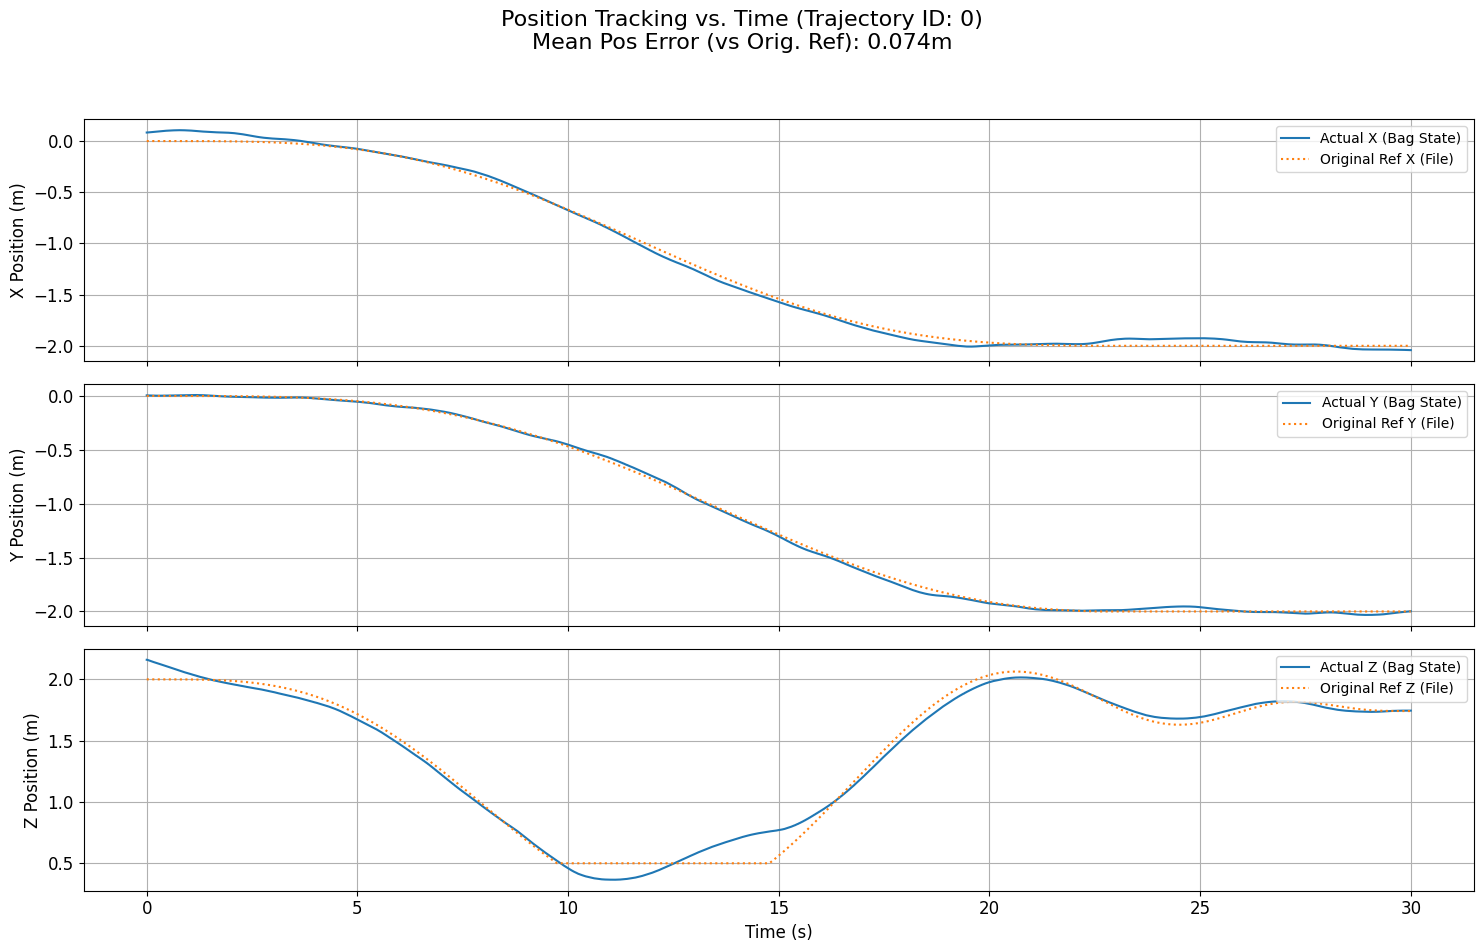

In [19]:
# Cell 5: Position Tracking Plots
if selected_data_valid:
    fig_pos, axs_pos = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
    fig_pos.suptitle(f'Position Tracking vs. Time (Trajectory ID: {trajectory_id_to_plot})\nMean Pos Error (vs Orig. Ref): {mean_pos_error:.3f}m', fontsize=16)
    
    pos_labels = ['X', 'Y', 'Z']
    for i in range(3):
        axs_pos[i].plot(time_vector, q_actual[:, i], label=f'Actual {pos_labels[i]} (Bag State)')
        axs_pos[i].plot(time_vector, pos_ref_original[:, i], label=f'Original Ref {pos_labels[i]} (File)', linestyle=':')
        axs_pos[i].set_ylabel(f'{pos_labels[i]} Position (m)')
        axs_pos[i].legend(loc='upper right')
        axs_pos[i].grid(True)
    axs_pos[2].set_xlabel('Time (s)')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
else:
    print("Skipping Position Plots: Selected data not valid.")

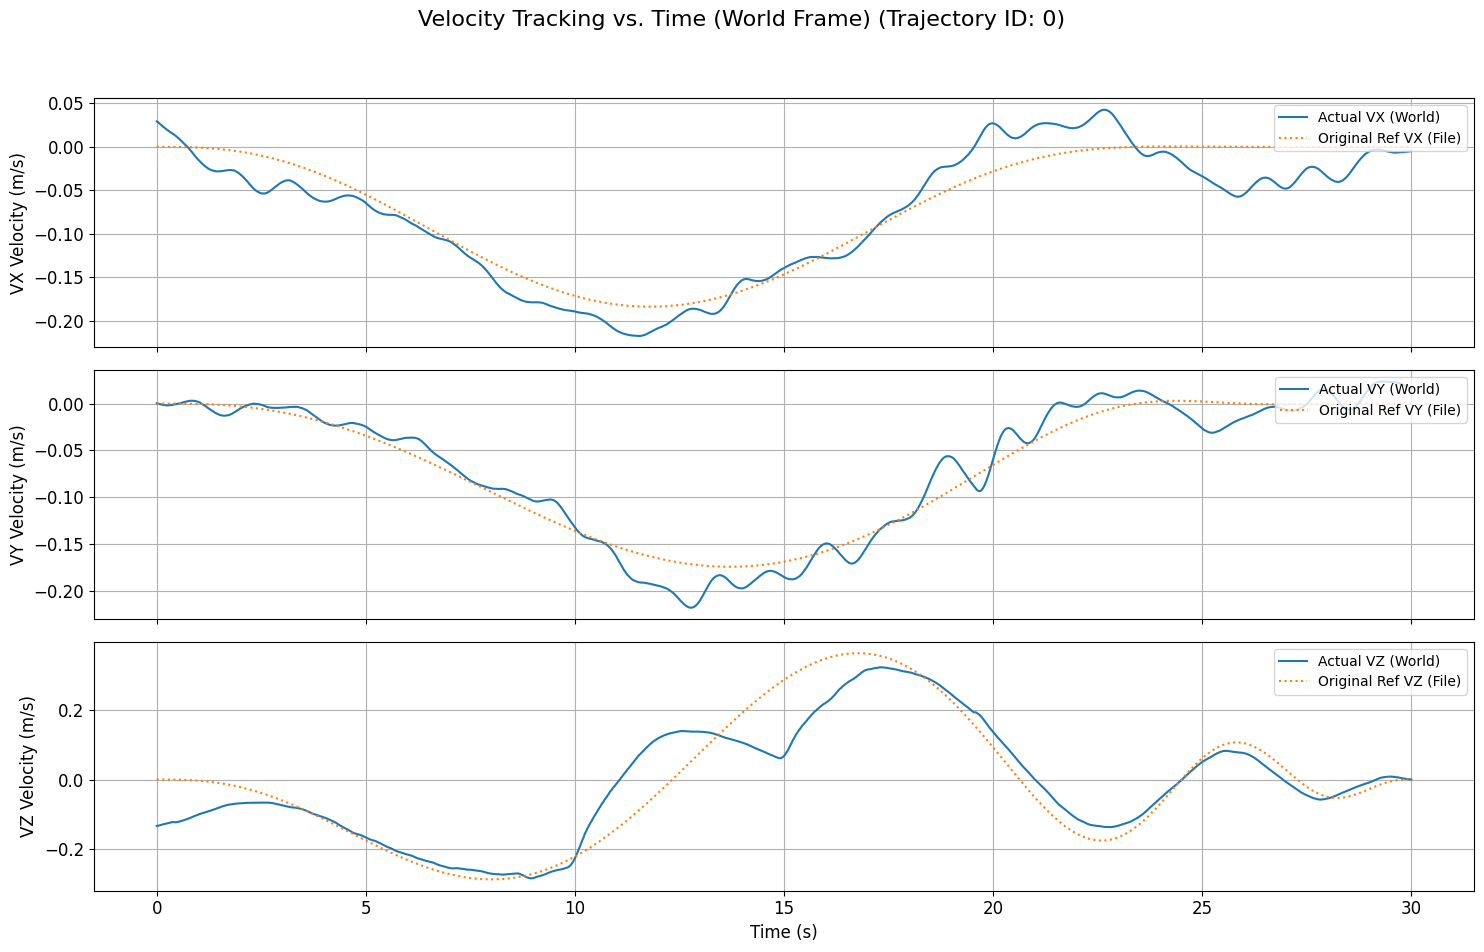

In [20]:
# Cell 6: Velocity Tracking Plots (World Frame)
if selected_data_valid:
    fig_vel, axs_vel = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
    fig_vel.suptitle(f'Velocity Tracking vs. Time (World Frame) (Trajectory ID: {trajectory_id_to_plot})', fontsize=16)
    
    vel_labels = ['VX', 'VY', 'VZ']
    for i in range(3):
        axs_vel[i].plot(time_vector, dq_actual_world[:, i], label=f'Actual {vel_labels[i]} (World)')
        axs_vel[i].plot(time_vector, vel_ref_original[:, i], label=f'Original Ref {vel_labels[i]} (File)', linestyle=':')
        axs_vel[i].set_ylabel(f'{vel_labels[i]} Velocity (m/s)')
        axs_vel[i].legend(loc='upper right')
        axs_vel[i].grid(True)
    axs_vel[2].set_xlabel('Time (s)')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
else:
    print("Skipping Velocity Plots: Selected data not valid.")

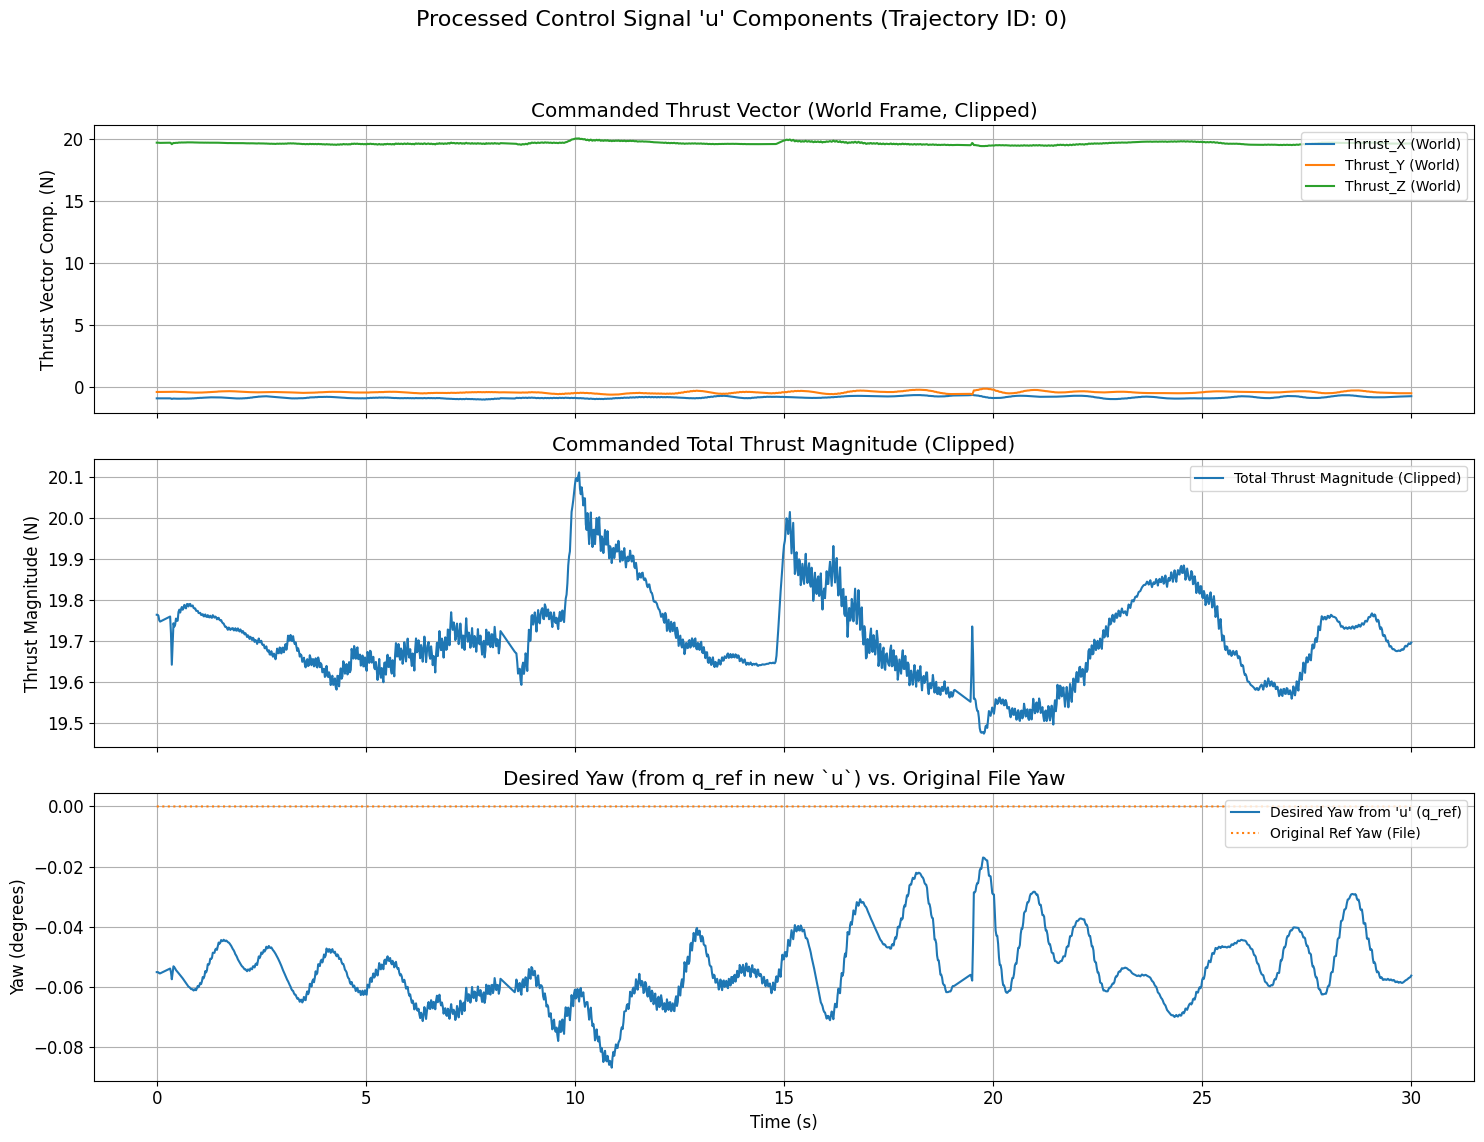

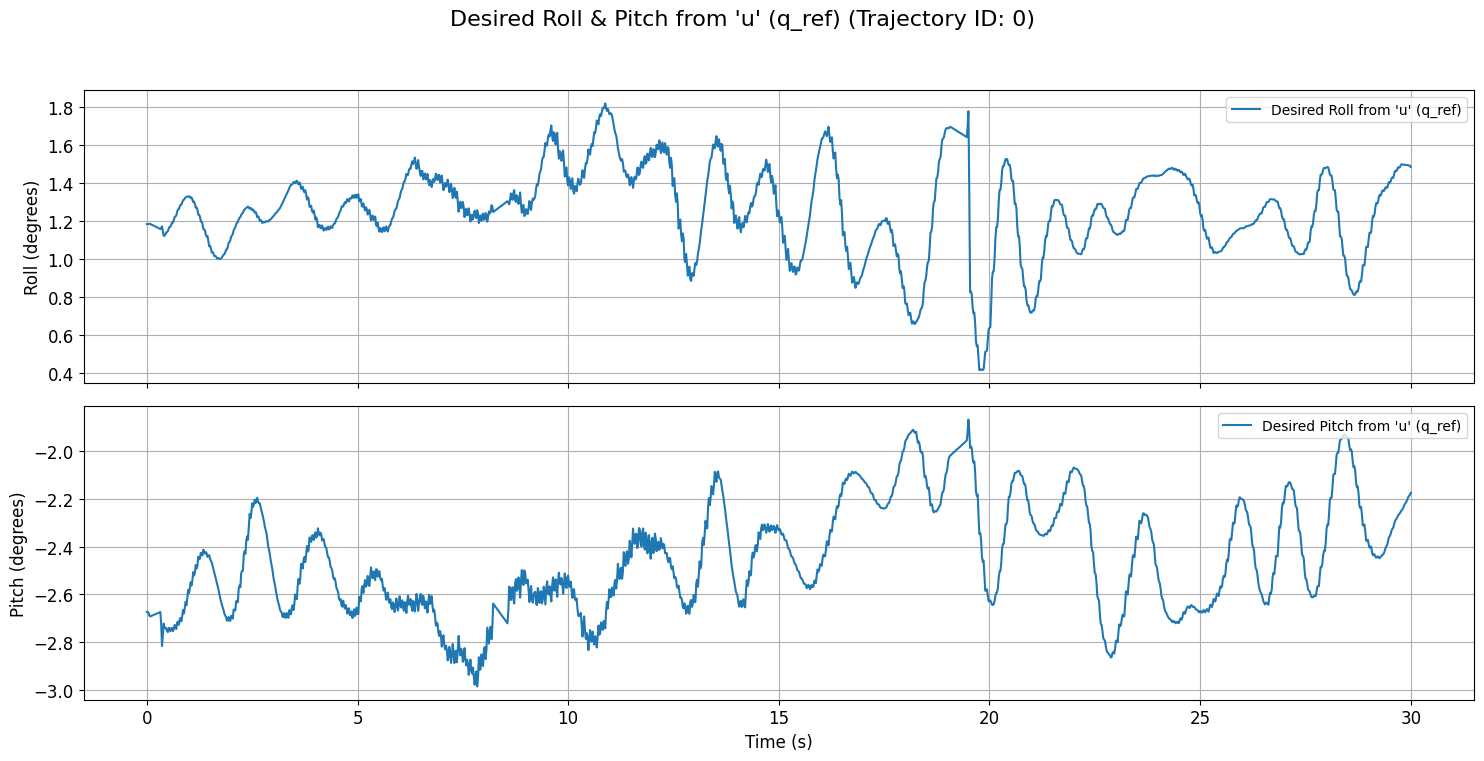

In [21]:
# Cell 7: Visualization of the new 'u' field components
if selected_data_valid:
    fig_u, axs_u = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
    fig_u.suptitle(f"Processed Control Signal 'u' Components (Trajectory ID: {trajectory_id_to_plot})", fontsize=16)

    # Subplot 1: Thrust Vector Components (World Frame)
    thrust_vec_labels = ['Thrust_X (World)', 'Thrust_Y (World)', 'Thrust_Z (World)']
    for i in range(3):
        axs_u[0].plot(time_vector, thrust_vector_ref_world[:, i], label=thrust_vec_labels[i])
    axs_u[0].set_ylabel('Thrust Vector Comp. (N)')
    axs_u[0].set_title('Commanded Thrust Vector (World Frame, Clipped)')
    axs_u[0].legend(loc='upper right')
    axs_u[0].grid(True)

    # Subplot 2: Total Thrust Magnitude
    axs_u[1].plot(time_vector, thrust_magnitude_ref, label='Total Thrust Magnitude (Clipped)')
    axs_u[1].set_ylabel('Thrust Magnitude (N)')
    axs_u[1].set_title('Commanded Total Thrust Magnitude (Clipped)')
    axs_u[1].legend(loc='upper right')
    axs_u[1].grid(True)
    
    # Subplot 3: Desired Yaw (from q_ref in 'u') vs Original File Yaw
    axs_u[2].plot(time_vector, yaw_ref_from_u_deg, label="Desired Yaw from 'u' (q_ref)")
    axs_u[2].plot(time_vector, psi_ref_original_deg, label='Original Ref Yaw (File)', linestyle=':')
    axs_u[2].set_ylabel('Yaw (degrees)')
    axs_u[2].set_title('Desired Yaw (from q_ref in new `u`) vs. Original File Yaw')
    axs_u[2].legend(loc='upper right')
    axs_u[2].grid(True)
    axs_u[2].set_xlabel('Time (s)')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # Optional: Plot Roll and Pitch from q_ref in 'u'
    fig_rp, axs_rp = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
    fig_rp.suptitle(f"Desired Roll & Pitch from 'u' (q_ref) (Trajectory ID: {trajectory_id_to_plot})", fontsize=16)
    
    axs_rp[0].plot(time_vector, np.rad2deg(euler_ref_from_u_rad[:, 0]), label="Desired Roll from 'u' (q_ref)")
    axs_rp[0].set_ylabel('Roll (degrees)')
    axs_rp[0].legend(loc='upper right')
    axs_rp[0].grid(True)

    axs_rp[1].plot(time_vector, np.rad2deg(euler_ref_from_u_rad[:, 1]), label="Desired Pitch from 'u' (q_ref)")
    axs_rp[1].set_ylabel('Pitch (degrees)')
    axs_rp[1].legend(loc='upper right')
    axs_rp[1].grid(True)
    axs_rp[1].set_xlabel('Time (s)')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

else:
    print("Skipping 'u' field visualization: Selected data not valid.")

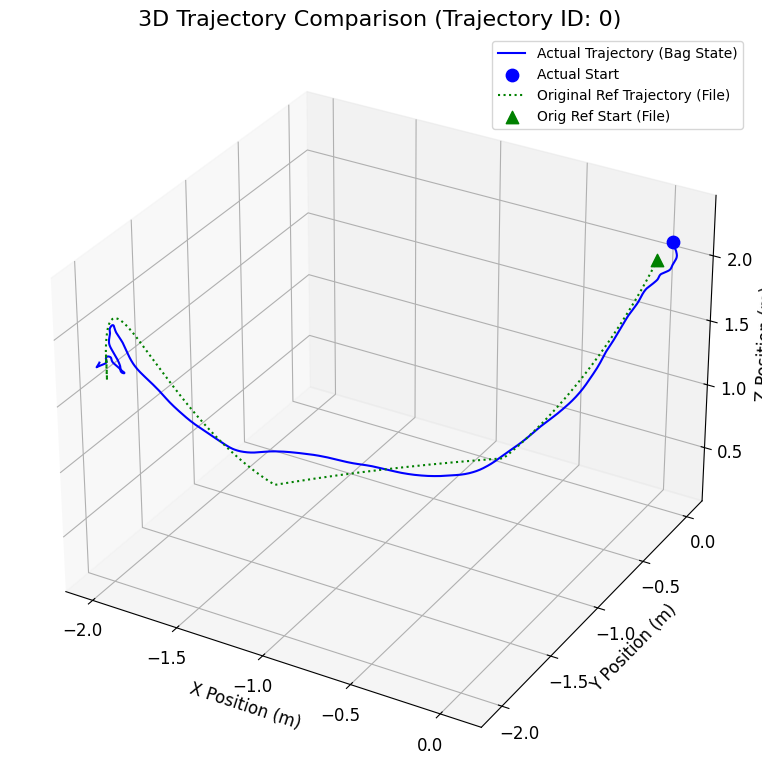

In [22]:
# Cell 8: 3D Trajectory Plot (Actual vs Original File Reference)
if selected_data_valid:
    fig_3d = plt.figure(figsize=(10, 8))
    ax_3d = fig_3d.add_subplot(111, projection='3d')
    
    if q_actual.shape[0] > 0:
        ax_3d.plot(q_actual[:, 0], q_actual[:, 1], q_actual[:, 2], label='Actual Trajectory (Bag State)', color='b')
        ax_3d.scatter(q_actual[0, 0], q_actual[0, 1], q_actual[0, 2], c='blue', marker='o', s=80, label='Actual Start', depthshade=False)
    
    if pos_ref_original.shape[0] > 0:
        ax_3d.plot(pos_ref_original[:, 0], pos_ref_original[:, 1], pos_ref_original[:, 2], label='Original Ref Trajectory (File)', color='g', linestyle=':')
        ax_3d.scatter(pos_ref_original[0, 0], pos_ref_original[0, 1], pos_ref_original[0, 2], c='green', marker='^', s=80, label='Orig Ref Start (File)', depthshade=False)
    
    ax_3d.set_xlabel('X Position (m)')
    ax_3d.set_ylabel('Y Position (m)')
    ax_3d.set_zlabel('Z Position (m)')
    ax_3d.set_title(f'3D Trajectory Comparison (Trajectory ID: {trajectory_id_to_plot})', fontsize=16)
    ax_3d.legend()
    ax_3d.grid(True)
    
    all_x_list = []
    all_y_list = []
    all_z_list = []
    if q_actual.shape[0] > 0:
        all_x_list.append(q_actual[:, 0]); all_y_list.append(q_actual[:, 1]); all_z_list.append(q_actual[:, 2])
    if pos_ref_original.shape[0] > 0:
        all_x_list.append(pos_ref_original[:, 0]); all_y_list.append(pos_ref_original[:, 1]); all_z_list.append(pos_ref_original[:, 2])

    if all_x_list: # Check if list is not empty
        all_x = np.concatenate(all_x_list)
        all_y = np.concatenate(all_y_list)
        all_z = np.concatenate(all_z_list)
        if len(all_x) > 0 : # Check if concatenated arrays are not empty
            max_range = np.array([all_x.max()-all_x.min(), all_y.max()-all_y.min(), all_z.max()-all_z.min()]).max() / 1.8
            if max_range < 0.1 or np.isnan(max_range) or np.isinf(max_range): max_range = 1.0 
            mid_x = (all_x.max()+all_x.min())*0.5; mid_y = (all_y.max()+all_y.min())*0.5; mid_z = (all_z.max()+all_z.min())*0.5
            ax_3d.set_xlim(mid_x - max_range, mid_x + max_range)
            ax_3d.set_ylim(mid_y - max_range, mid_y + max_range)
            ax_3d.set_zlim(mid_z - max_range, mid_z + max_range)
    
    plt.tight_layout()
    plt.show()
else:
    print("Skipping 3D Trajectory Plot: Selected data not valid.")